vlm=2 counts: [0, 12933, 50167, 0]
vlm=3 counts: [0, 10194, 46064, 0]
vlm=6 counts: [49833, 25341, 32622, 0]


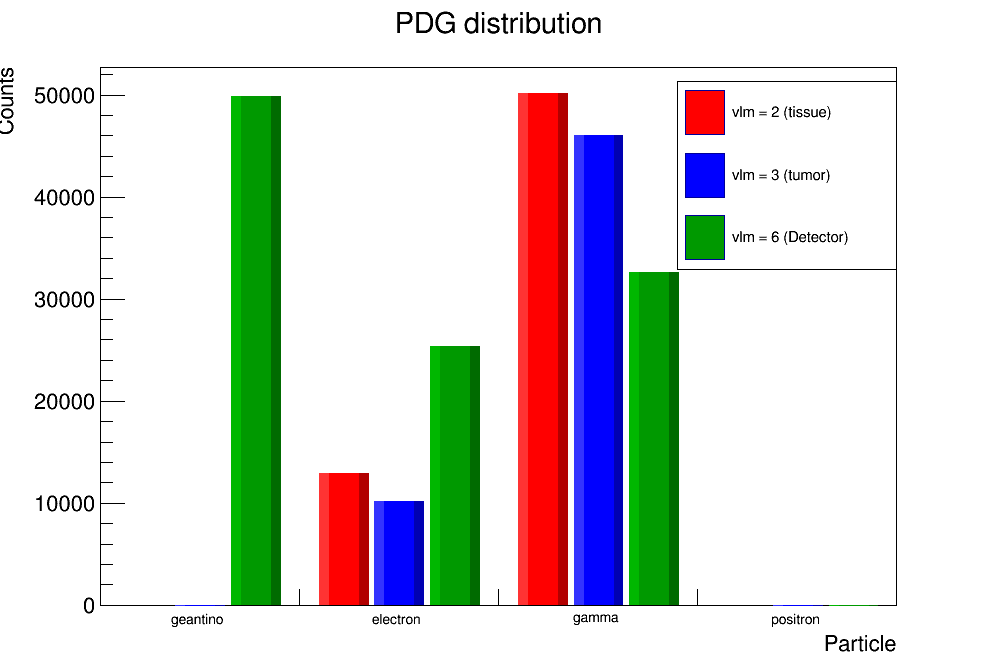

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file pdg_bar_plot.png has been created


In [7]:
import ROOT
from IPython.display import Image, display

%jsroot on

f = ROOT.TFile.Open("tumor.root")
t = f.Get("t")

c = ROOT.TCanvas("c", "pdg for selected volumes", 1000, 700)
c.cd()

legend = ROOT.TLegend(0.68, 0.60, 0.90, 0.88)
legend.SetBorderSize(1)
legend.SetFillStyle(0)
legend.SetTextSize(0.025)

colors = [ROOT.kRed, ROOT.kBlue, ROOT.kGreen+2]

names = {
    2: "tissue",
    3: "tumor",
    6: "Detector",
}

selected_vlm = [2, 3, 6]
first = True
hist_list = []

pdg_labels = {
    -11: "positron",
     11: "electron",
     22: "gamma",
      0: "geantino"
}

pdg_order = [ 0, 11, 22, -11 ]

for i, vlm in enumerate(selected_vlm):
    hname = f"h_vlm_{vlm}"

    old = ROOT.gROOT.FindObject(hname)
    if old:
        old.Delete()

    h = ROOT.TH1F(
        hname,
        "PDG distribution;Particle;Counts",
        len(pdg_order), 0, len(pdg_order)
    )

    for j, pdg in enumerate(pdg_order):
        count = t.GetEntries(f"vlm=={vlm} && pdg=={pdg}")
        h.SetBinContent(j + 1, count)
        h.GetXaxis().SetBinLabel(j + 1, pdg_labels[pdg])

    print(f"vlm={vlm} counts:",
          [t.GetEntries(f"vlm=={vlm} && pdg=={p}") for p in pdg_order])

    h.SetFillColor(colors[i])
    h.SetBarWidth(0.25)
    h.SetBarOffset(0.1 + i * 0.28)
    h.SetStats(0)

    if first:
        h.Draw("bar2")
        first = False
    else:
        h.Draw("bar2 same")

    label = f"vlm = {vlm}"
    if vlm in names:
        label += f" ({names[vlm]})"

    legend.AddEntry(h, label, "f")
    hist_list.append(h)

legend.Draw()
c.Modified()
c.Update()

c.SaveAs("pdg_bar_plot.png")
display(Image(filename="pdg_bar_plot.png"))